In [20]:
# =========================================
# LIBRARIES
# =========================================
!pip install xgboost shap

import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.stats.mstats import winsorize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import shap
from google.colab import files

import os
import json

os.makedirs("outputs", exist_ok=True)

In [21]:
# =========================================
# PIPELINE CUSTOM TRANSFORMER
# =========================================
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, limits=(0.05, 0.05)):
        self.limits = limits

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.array(X, copy=True)
        for i in range(X.shape[1]):
            X[:, i] = winsorize(X[:, i], limits=self.limits)
        return X

In [22]:
# =========================================
# LOAD DATA
# =========================================
uploaded = files.upload()
df = pd.read_csv('heart_disease.csv')

Saving heart_disease.csv to heart_disease (1).csv


In [23]:
display(df.head())
print("Dataset shape:", df.shape)
print("Duplicates:", df.duplicated().sum())
print(df["target_binary"].value_counts())
print(df.isnull().sum())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target_binary
0,63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0.0,6.0,0,0
1,67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3.0,3.0,2,1
2,67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2.0,7.0,1,1
3,37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0.0,3.0,0,0
4,41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0.0,3.0,0,0


Dataset shape: (1024, 15)
Duplicates: 0
target_binary
0    554
1    470
Name: count, dtype: int64
age              0
sex              0
cp               0
trestbps         0
chol             0
fbs              0
restecg          0
thalach          0
exang            0
oldpeak          0
slope            0
ca               0
thal             0
num              0
target_binary    0
dtype: int64


In [24]:
# =========================================
# SPLIT
# =========================================
x = df.drop(['target_binary', "num"], axis=1)
y = df['target_binary']

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

In [25]:
# =========================================
# EVALUATION FUNCTION
# =========================================
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

In [26]:
# ===============
# CV FUNCTION
# ===============
def evaluate_with_cv(model, X, y, seeds=[42,52,62], cv=5):
    results = []

    for seed in seeds:
        kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
        scores = cross_val_score(model, X, y, cv=kfold, scoring='f1')
        results.append(scores.mean())

    return np.mean(results), np.std(results)


In [27]:
# ===================
# RESULTS STORAGE
# ===================
results = []
cv_results = []

In [28]:
# =========================================
# BASELINE PIPELINE
# =========================================
for name, model in {
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier(eval_metric='logloss', random_state=42)
}.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model)
    ])

    res = evaluate_model(pipeline, X_train, X_test, y_train, y_test)
    mean_cv, std_cv = evaluate_with_cv(pipeline, X_train, y_train)

    results.append(["Baseline", name, res["F1"]])
    cv_results.append(["Baseline", name, mean_cv, std_cv])


In [29]:
# =========================================
# WINSORIZATION PIPELINE
# =========================================
for name, model in {
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier(eval_metric='logloss', random_state=42)
}.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("winsorizer", Winsorizer()),
        ("model", model)
    ])

    res = evaluate_model(pipeline, X_train, X_test, y_train, y_test)
    mean_cv, std_cv = evaluate_with_cv(pipeline, X_train, y_train)

    results.append(["Winsor", name, res["F1"]])
    cv_results.append(["Winsor", name, mean_cv, std_cv])

In [30]:
# =========================================
# INTRODUCE MISSING DATA
# =========================================
def introduce_missing(X, rate=0.1, seed=42):
    np.random.seed(seed)
    X_missing = X.copy()
    mask = np.random.rand(*X.shape) < rate
    X_missing[mask] = np.nan
    return X_missing

X_train_miss = introduce_missing(X_train, 0.1)
X_test_miss = introduce_missing(X_test, 0.1)

In [31]:
# =========================================
# MEAN IMPUTATION (PIPELINE)
# =========================================
for name, model in {
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier(eval_metric='logloss', random_state=42)
}.items():

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("model", model)
    ])

    res = evaluate_model(pipeline, X_train_miss, X_test_miss, y_train, y_test)
    mean_cv, std_cv = evaluate_with_cv(pipeline, X_train_miss, y_train)

    results.append(["Mean", name, res["F1"]])
    cv_results.append(["Mean", name, mean_cv, std_cv])

In [32]:
# =========================================
#  KNN IMPUTATION (PIPELINE)
# =========================================
for name, model in {
    "RF": RandomForestClassifier(random_state=42),
    "XGB": XGBClassifier(eval_metric='logloss', random_state=42)
}.items():

    pipeline = Pipeline([
        ("imputer", KNNImputer(n_neighbors=5)),
        ("model", model)
    ])

    res = evaluate_model(pipeline, X_train_miss, X_test_miss, y_train, y_test)
    mean_cv, std_cv = evaluate_with_cv(pipeline, X_train_miss, y_train)

    results.append(["KNN", name, res["F1"]])
    cv_results.append(["KNN", name, mean_cv, std_cv])

In [33]:
# =========================================
# RESULTS TABLES
# =========================================
results_df = pd.DataFrame(results, columns=["Experiment", "Model", "F1"])
cv_results_df = pd.DataFrame(cv_results, columns=["Experiment", "Model", "Mean_F1", "Std"])

print("\nTest Results:")
display(results_df)

print("\nCross-Validation Results:")
display(cv_results_df)


Test Results:


,Experiment,Model,F1
0,Baseline,RF,0.835979
1,Baseline,XGB,0.847826
2,Winsor,RF,0.844920
3,Winsor,XGB,0.837989
4,Mean,RF,0.835165
5,Mean,XGB,0.826816
6,KNN,RF,0.806630
7,KNN,XGB,0.817680



Cross-Validation Results:


,Experiment,Model,Mean_F1,Std
0,Baseline,RF,0.883530,0.001109
1,Baseline,XGB,0.872695,0.009560
2,Winsor,RF,0.881645,0.003778
3,Winsor,XGB,0.872998,0.003131
4,Mean,RF,0.861377,0.003965
5,Mean,XGB,0.838601,0.007556
6,KNN,RF,0.854837,0.007272
7,KNN,XGB,0.844251,0.005878


In [34]:
# =========================================
# SAVE RESULTS
# =========================================

results_df.to_csv("outputs/test_results.csv", index=False)
cv_results_df.to_csv("outputs/cv_results.csv", index=False)


with open("outputs/test_results.json", "w") as f:
    json.dump(results, f, indent=4)

with open("outputs/cv_results.json", "w") as f:
    json.dump(cv_results, f, indent=4)

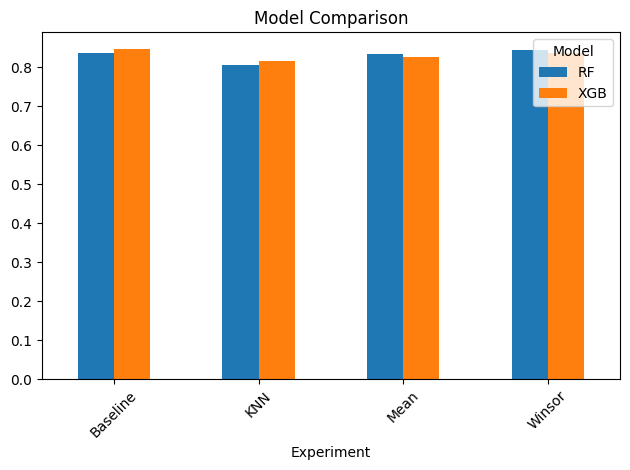

In [35]:
# =========================================
# PLOT
# =========================================
plot = results_df.pivot(index="Experiment", columns="Model", values="F1")

plot.plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("outputs/model_comparison.png")   # ✅ ADD THIS
plt.show()

/tmp/ipykernel_41968/1648603455.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_transformed, show=False)


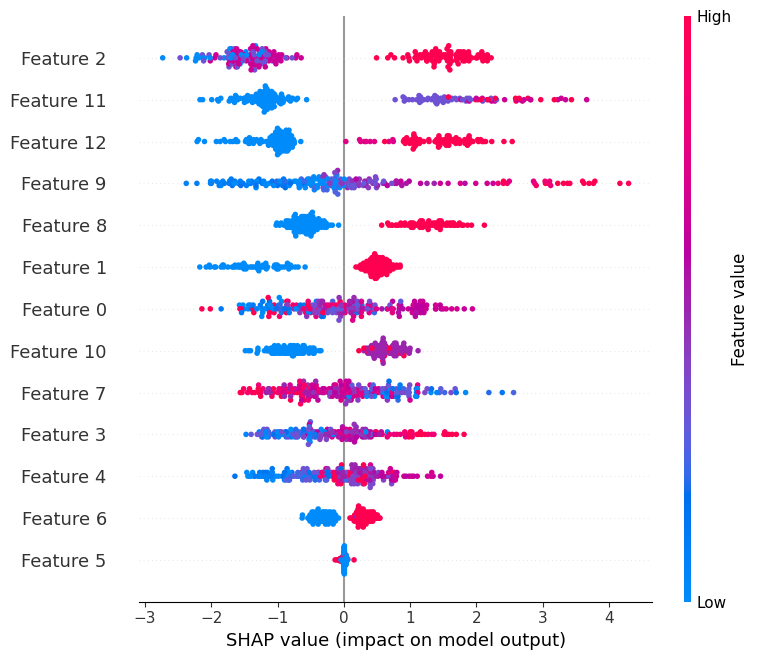

In [36]:
# =========================================
# SHAP (PIPELINE)
# =========================================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBClassifier(eval_metric='logloss', random_state=42))
])

pipeline.fit(X_train, y_train)

model = pipeline.named_steps["model"]
X_transformed = pipeline[:-1].transform(X_test)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(shap_values, X_transformed, show=False)
plt.savefig("outputs/shap_summary.png")
plt.show()
